# UAPOML — Week 2 Problem Set
### Portfolio Management & Machine Learning

**Topics:** Portfolio Metrics · KNN · Linear Regression · Backtesting · Risk Analysis

This notebook answers all 10 problems. Problems 7–9 implement KNN / Linear Regression
**from scratch** (NumPy only); scikit-learn is used **only** for verification in Problem 9.

> Note on data: several problems need long price histories that the tiny tables in the
> prompt don't provide, so where specified we generate reproducible synthetic series with
> fixed seeds (exactly as the assignment instructs).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.random.seed(42)  # global reproducibility

---
## Section A — Portfolio Fundamentals & Risk Metrics

## Problem 1 — Portfolio Construction & Daily Returns

In [ ]:
# --- (a) Build prices DataFrame and daily % returns ---
data = {
    'RELIANCE':   [2800, 2850, 2830, 2900, 2880, 2950],
    'INFY':       [1450, 1470, 1460, 1490, 1510, 1500],
    'HDFCBANK':   [1600, 1580, 1610, 1625, 1615, 1640],
    'TATAMOTORS': [520,  535,  528,  540,  555,  548],
}
days = [f'Day {i}' for i in range(1, 7)]
prices_df = pd.DataFrame(data, index=days)

returns_df = prices_df.pct_change().dropna()
print("Prices:\n", prices_df, "\n")
print("Daily returns (%):\n", (returns_df * 100).round(3))

Prices:
        RELIANCE  INFY  HDFCBANK  TATAMOTORS
Day 1      2800  1450      1600         520
Day 2      2850  1470      1580         535
Day 3      2830  1460      1610         528
Day 4      2900  1490      1625         540
Day 5      2880  1510      1615         555
Day 6      2950  1500      1640         548 

Daily returns (%):
        RELIANCE   INFY  HDFCBANK  TATAMOTORS
Day 2     1.786  1.379    -1.250       2.885
Day 3    -0.702 -0.680     1.899      -1.308
Day 4     2.473  2.055     0.932       2.273
Day 5    -0.690  1.342    -0.615       2.778
Day 6     2.431 -0.662     1.548      -1.261


Units purchased on Day 1:
 RELIANCE       89.286
INFY          172.414
HDFCBANK      156.250
TATAMOTORS    480.769
dtype: float64 

Daily portfolio value:
 Day 1    1000000.00
Day 2    1011999.10
Day 3    1009811.36
Day 4    1029346.76
Day 5    1036658.36
Day 6    1041725.09
dtype: float64


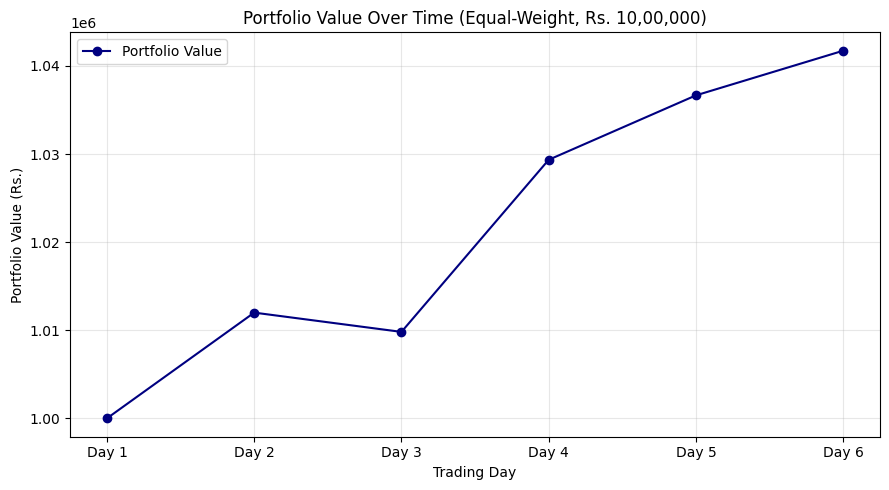

In [ ]:
# --- (b) Units on Day 1, daily portfolio value (vectorised), plot ---
capital = 1_000_000
weights = np.array([0.25, 0.25, 0.25, 0.25])

invest_per_asset = capital * weights                 # 2,50,000 each
units = invest_per_asset / prices_df.iloc[0].values  # units bought on Day 1
units = pd.Series(units, index=prices_df.columns)
print("Units purchased on Day 1:\n", units.round(3), "\n")

# Vectorised portfolio value: prices . units  (matrix multiplication)
portfolio_value = prices_df.dot(units)
print("Daily portfolio value:\n", portfolio_value.round(2))

plt.figure()
plt.plot(portfolio_value.index, portfolio_value.values, marker='o', color='navy')
plt.title('Portfolio Value Over Time (Equal-Weight, Rs. 10,00,000)')
plt.xlabel('Trading Day'); plt.ylabel('Portfolio Value (Rs.)')
plt.legend(['Portfolio Value']); plt.tight_layout(); plt.show()

In [ ]:
# --- (c) Annualised volatility (252 trading days) ---
port_returns = portfolio_value.pct_change().dropna()
sigma_daily  = port_returns.std(ddof=1)
sigma_annual = sigma_daily * np.sqrt(252)
print(f"Daily portfolio volatility : {sigma_daily:.5f}")
print(f"Annualised volatility      : {sigma_annual:.4f}  ({sigma_annual*100:.2f}%)")

Daily portfolio volatility : 0.00803
Annualised volatility      : 0.1275  (12.75%)


## Problem 2 — Risk Metrics: VaR, CVaR & Drawdowns

We extend the portfolio to a longer synthetic return series
($\mu=0.001,\ \sigma=0.015$) so the tail metrics are meaningful.

In [ ]:
# Synthetic daily portfolio returns (reused in Problem 3)
np.random.seed(1)
N_DAYS = 252
sim_returns = np.random.normal(0.001, 0.015, N_DAYS)
sim_returns = pd.Series(sim_returns, name='returns')
print("Simulated", N_DAYS, "daily returns. First 5:", sim_returns.head().round(4).tolist())

Simulated 252 daily returns. First 5: [0.0254, -0.0082, -0.0069, -0.0151, 0.014]


In [ ]:
# --- (a) Historical VaR at 95% and 99% ---
def historical_var(r, alpha):
    return -np.percentile(r, (1 - alpha) * 100)

VaR_95 = historical_var(sim_returns, 0.95)
VaR_99 = historical_var(sim_returns, 0.99)
print(f"95% VaR = {VaR_95:.4f}  -> on ~95% of days the daily loss should not exceed "
      f"{VaR_95*100:.2f}% (i.e. ~5% chance of a worse loss).")
print(f"99% VaR = {VaR_99:.4f}  -> only ~1% of days are expected to lose more than "
      f"{VaR_99*100:.2f}%.")

95% VaR = 0.0199  -> on ~95% of days the daily loss should not exceed 1.99% (i.e. ~5% chance of a worse loss).
99% VaR = 0.0296  -> only ~1% of days are expected to lose more than 2.96%.


In [ ]:
# --- (b) Conditional VaR (Expected Shortfall) ---
def cvar(r, alpha):
    threshold = np.percentile(r, (1 - alpha) * 100)   # cutoff return
    tail = r[r <= threshold]
    return -tail.mean()

CVaR_95 = cvar(sim_returns, 0.95)
CVaR_99 = cvar(sim_returns, 0.99)
print(f"95% CVaR = {CVaR_95:.4f}   (avg loss on the worst 5% of days)")
print(f"99% CVaR = {CVaR_99:.4f}   (avg loss on the worst 1% of days)")
print("\nCVaR is more informative than VaR because VaR only marks the *threshold* of the "
      "tail,\nwhile CVaR averages the actual losses *beyond* it — capturing how bad the bad "
      "days really are.")

95% CVaR = 0.0264   (avg loss on the worst 5% of days)
99% CVaR = 0.0330   (avg loss on the worst 1% of days)

CVaR is more informative than VaR because VaR only marks the *threshold* of the tail,
while CVaR averages the actual losses *beyond* it — capturing how bad the bad days really are.


Maximum Drawdown = 0.0939  (9.39%)


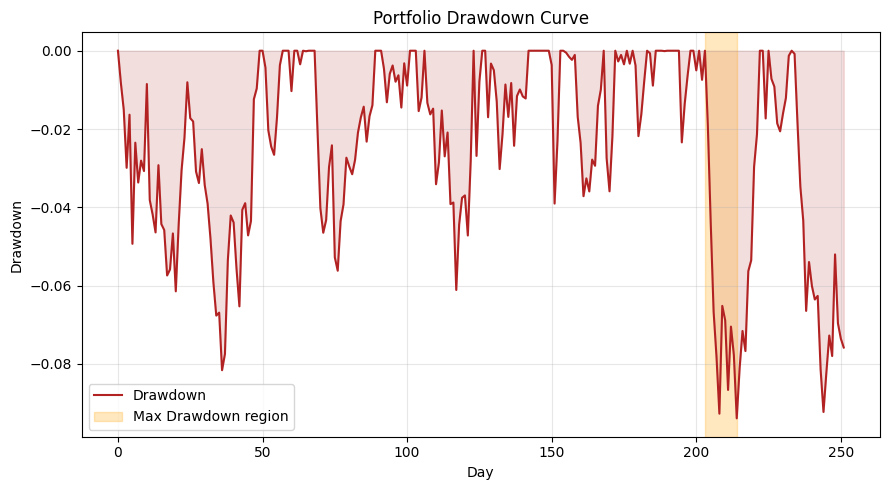

In [ ]:
# --- (c) Maximum Drawdown + drawdown curve ---
cum_value   = (1 + sim_returns).cumprod()
running_max = cum_value.cummax()
drawdown    = (running_max - cum_value) / running_max

max_dd      = drawdown.max()
trough_idx  = drawdown.idxmax()
peak_idx    = cum_value[:trough_idx].idxmax()
print(f"Maximum Drawdown = {max_dd:.4f}  ({max_dd*100:.2f}%)")

plt.figure()
plt.plot(drawdown.index, -drawdown.values, color='firebrick', label='Drawdown')
plt.fill_between(drawdown.index, -drawdown.values, 0, color='firebrick', alpha=0.15)
plt.axvspan(peak_idx, trough_idx, color='orange', alpha=0.25, label='Max Drawdown region')
plt.title('Portfolio Drawdown Curve')
plt.xlabel('Day'); plt.ylabel('Drawdown'); plt.legend(); plt.tight_layout(); plt.show()

## Problem 3 — Risk-Adjusted Performance Metrics

In [ ]:
# Reuse the 252-day synthetic series from Problem 2
returns = sim_returns.copy()
Rf_annual = 0.06

# --- (a) Sharpe Ratio (annualised) ---
ann_return = returns.mean() * 252
ann_vol    = returns.std(ddof=1) * np.sqrt(252)
sharpe = (ann_return - Rf_annual) / ann_vol
print(f"Annualised return     : {ann_return:.4f}")
print(f"Annualised volatility : {ann_vol:.4f}")
print(f"Sharpe Ratio          : {sharpe:.4f}")

Annualised return     : 0.5296
Annualised volatility : 0.2264
Sharpe Ratio          : 2.0743


In [ ]:
# --- (b) Sortino Ratio (downside deviation from negative returns only) ---
downside = returns[returns < 0]
downside_dev_daily = downside.std(ddof=1)          # uses only negative returns
ann_downside = downside_dev_daily * np.sqrt(252)
sortino = (ann_return - Rf_annual) / ann_downside
print(f"Annualised downside deviation : {ann_downside:.4f}")
print(f"Sortino Ratio                 : {sortino:.4f}")
print("\nSortino penalises less than Sharpe when upside volatility is high because it ignores "
      "upward swings entirely —\nonly downside moves count in the denominator, so 'good' "
      "volatility no longer inflates the risk measure.")

Annualised downside deviation : 0.1288
Sortino Ratio                 : 3.6444

Sortino penalises less than Sharpe when upside volatility is high because it ignores upward swings entirely —
only downside moves count in the denominator, so 'good' volatility no longer inflates the risk measure.


In [ ]:
# --- (c) Comparison table ---
metrics = pd.DataFrame({
    'Metric': ['Sharpe Ratio', 'Sortino Ratio'],
    'Value' : [round(sharpe, 4), round(sortino, 4)]
}).set_index('Metric')
print(metrics)
print("\nFor an asymmetric strategy (big upside, limited downside) the Sortino Ratio is more "
      "appropriate,\nsince Sharpe unfairly punishes the desirable upside volatility.")

                Value
Metric               
Sharpe Ratio   2.0743
Sortino Ratio  3.6444

For an asymmetric strategy (big upside, limited downside) the Sortino Ratio is more appropriate,
since Sharpe unfairly punishes the desirable upside volatility.


## Problem 4 — Backtesting a Simple Moving-Average Crossover

In [ ]:
# Random-walk price series: P_t = P_{t-1}(1 + eps), eps ~ N(0.001, 0.018)
np.random.seed(2)
P0, n = 1000, 200
eps = np.random.normal(0.001, 0.018, n)
price = P0 * np.cumprod(1 + eps)
asset = pd.DataFrame({'Close': price})

# --- (a) SMA crossover signal ---
asset['SMA10'] = asset['Close'].rolling(10).mean()
asset['SMA30'] = asset['Close'].rolling(30).mean()
asset['signal'] = 0
asset.loc[asset['SMA10'] > asset['SMA30'], 'signal'] = 1    # long
asset.loc[asset['SMA10'] < asset['SMA30'], 'signal'] = -1   # short
asset.loc[asset['SMA30'].isna(), 'signal'] = 0              # hold until both SMAs exist
crossovers = asset['signal'].diff().fillna(0)
print("Number of crossover events:", int((crossovers != 0).sum()))
print(asset[['Close','SMA10','SMA30','signal']].tail())

Number of crossover events: 8
           Close        SMA10        SMA30  signal
195  1193.308205  1179.498096  1137.100465       1
196  1198.376634  1183.236048  1143.552542       1
197  1211.507195  1188.877344  1150.108919       1
198  1235.246101  1196.030322  1154.921025       1
199  1229.166165  1201.155576  1158.956656       1


Strategy cumulative return    : -9.58%


Buy & Hold cumulative return  : 23.72%


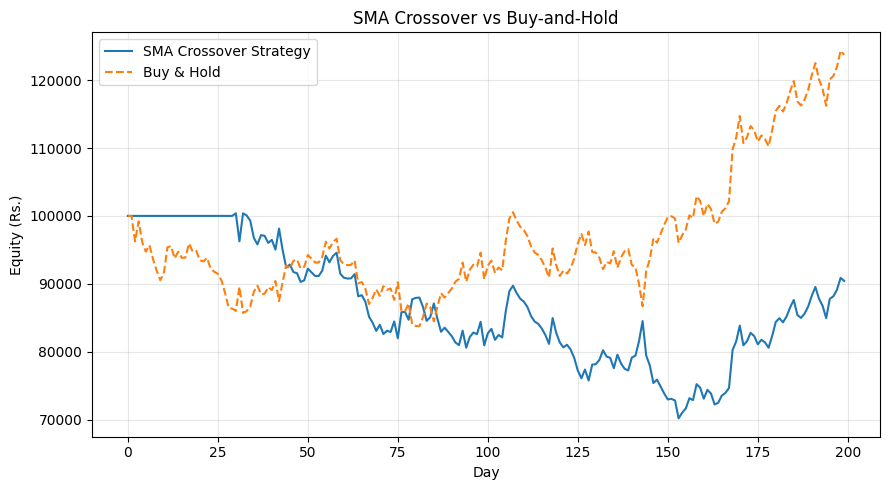

In [ ]:
# --- (b) Backtest vs buy-and-hold ---
asset['ret'] = asset['Close'].pct_change()
# trade tomorrow on today's signal (shift to avoid look-ahead)
asset['strat_ret'] = asset['signal'].shift(1) * asset['ret']

init_capital = 100_000
asset['strat_equity'] = init_capital * (1 + asset['strat_ret'].fillna(0)).cumprod()
asset['bh_equity']    = init_capital * (1 + asset['ret'].fillna(0)).cumprod()

strat_cum = asset['strat_equity'].iloc[-1] / init_capital - 1
bh_cum    = asset['bh_equity'].iloc[-1] / init_capital - 1
print(f"Strategy cumulative return    : {strat_cum*100:.2f}%")
print(f"Buy & Hold cumulative return  : {bh_cum*100:.2f}%")

plt.figure()
plt.plot(asset.index, asset['strat_equity'], label='SMA Crossover Strategy')
plt.plot(asset.index, asset['bh_equity'], label='Buy & Hold', linestyle='--')
plt.title('SMA Crossover vs Buy-and-Hold')
plt.xlabel('Day'); plt.ylabel('Equity (Rs.)'); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# --- (c) Win Rate & Profit Factor (per holding period / trade) ---
sig = asset['signal'].shift(1).fillna(0)
trade_id = (sig != sig.shift()).cumsum()           # new id whenever position changes
trade_ret = asset['strat_ret'].groupby(trade_id).apply(lambda x: (1 + x.fillna(0)).prod() - 1)
trade_ret = trade_ret[sig.groupby(trade_id).first() != 0]  # ignore flat/hold blocks

wins = (trade_ret > 0).sum()
total = len(trade_ret)
win_rate = wins / total if total else np.nan
gains  = trade_ret[trade_ret > 0].sum()
losses = -trade_ret[trade_ret < 0].sum()
profit_factor = gains / losses if losses else np.inf
print(f"Total trades : {total}")
print(f"Win Rate     : {win_rate*100:.1f}%")
print(f"Profit Factor: {profit_factor:.2f}")
print("\nNo — PF > 1 only means gross profit exceeds gross loss on the *backtest*. It says "
      "nothing about\nstatistical significance, transaction costs, drawdown, or whether the "
      "edge survives out-of-sample.")

Total trades : 8
Win Rate     : 25.0%
Profit Factor: 0.79

No — PF > 1 only means gross profit exceeds gross loss on the *backtest*. It says nothing about
statistical significance, transaction costs, drawdown, or whether the edge survives out-of-sample.


---
## Section B — Machine Learning Applications

## Problem 5 — Feature Engineering (shared by Problems 6–9)

Dataset shape: (281, 7)
Class balance:
 target
0    0.48
1    0.52
Name: proportion, dtype: float64


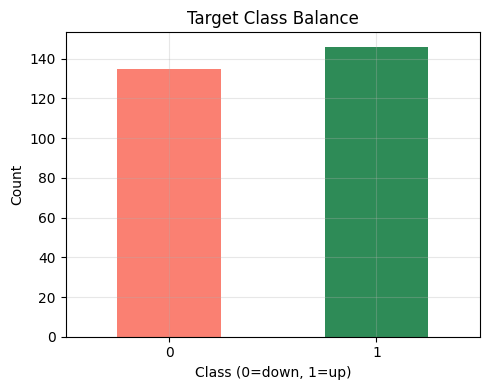

In [ ]:
# Random-walk price series, P0 = 500, 300 days
np.random.seed(3)
P0, n = 500, 300
eps = np.random.normal(0.001, 0.018, n)
px = P0 * np.cumprod(1 + eps)
df = pd.DataFrame({'Close': px})

# --- (a) Features (vectorised, no loops) ---
df['Return_1d']    = df['Close'].pct_change()
df['SMA_5']        = df['Close'].rolling(5).mean()
df['SMA_20']       = df['Close'].rolling(20).mean()
df['Volatility_10']= df['Return_1d'].rolling(10).std()
df['Momentum_5']   = df['Close'] - df['Close'].shift(5)

# --- (b) Binary target: 1 if next-day return > 0 ---
df['target'] = (df['Return_1d'].shift(-1) > 0).astype(int)

df = df.dropna().reset_index(drop=True)
feature_cols = ['Return_1d', 'SMA_5', 'SMA_20', 'Volatility_10', 'Momentum_5']
print("Dataset shape:", df.shape)

balance = df['target'].value_counts(normalize=True).sort_index()
print("Class balance:\n", balance.round(3))

plt.figure(figsize=(5,4))
df['target'].value_counts().sort_index().plot(kind='bar', color=['salmon','seagreen'])
plt.title('Target Class Balance'); plt.xlabel('Class (0=down, 1=up)')
plt.ylabel('Count'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [ ]:
# --- (c) Manual Min-Max scaling ---
X_raw = df[feature_cols].values.astype(float)
X_min = X_raw.min(axis=0)
X_max = X_raw.max(axis=0)
X_scaled = (X_raw - X_min) / (X_max - X_min)
y = df['target'].values

print("Scaled feature ranges (min, max):")
print(np.round(X_scaled.min(axis=0), 2), np.round(X_scaled.max(axis=0), 2))
print("\nScaling is critical for KNN because distances are dominated by large-magnitude "
      "features\n(e.g. Momentum_5 in price units vs Return_1d ~0.01). Without scaling the "
      "neighbour search\nwould essentially ignore the small-scale features.")

Scaled feature ranges (min, max):
[0. 0. 0. 0. 0.] [1. 1. 1. 1. 1.]

Scaling is critical for KNN because distances are dominated by large-magnitude features
(e.g. Momentum_5 in price units vs Return_1d ~0.01). Without scaling the neighbour search
would essentially ignore the small-scale features.


## Problem 6 — K-Nearest Neighbours from Scratch

In [ ]:
# --- (a) Distance + KNN predictor (NumPy only) ---
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def knn_predict(X_train, y_train, X_test, k):
    preds = np.empty(len(X_test), dtype=int)
    for i, x in enumerate(X_test):
        dists = np.array([euclidean_distance(x, xt) for xt in X_train])
        nn_idx = np.argsort(dists)[:k]               # k nearest
        preds[i] = np.bincount(y_train[nn_idx]).argmax()  # majority vote
    return preds

Train: 224   Test: 57


k= 3  accuracy=0.456
k= 5  accuracy=0.596
k= 7  accuracy=0.632


k=11  accuracy=0.649


k=15  accuracy=0.667
Optimal k: 15


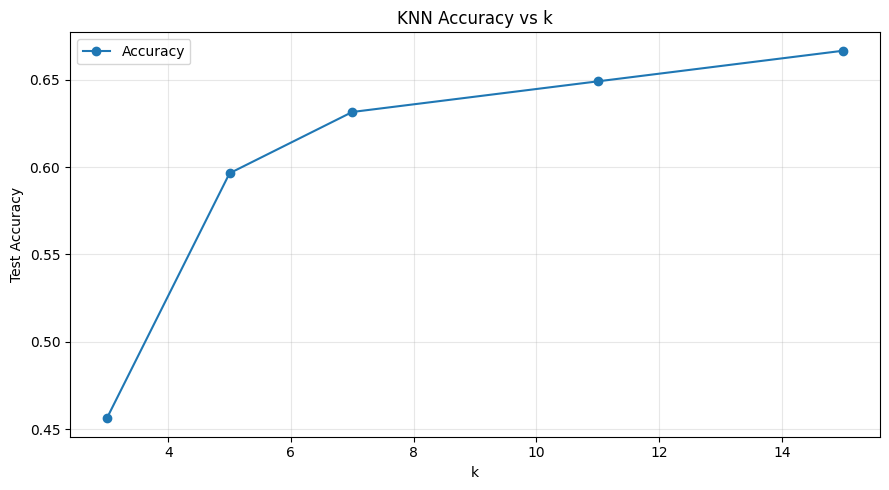

In [ ]:
# --- (b) Chronological 80/20 split, sweep k ---
split = int(0.8 * len(X_scaled))
X_tr, X_te = X_scaled[:split], X_scaled[split:]
y_tr, y_te = y[:split], y[split:]
print(f"Train: {len(X_tr)}   Test: {len(X_te)}")

k_values = [3, 5, 7, 11, 15]
accuracies = []
for k in k_values:
    pred = knn_predict(X_tr, y_tr, X_te, k)
    acc = (pred == y_te).mean()
    accuracies.append(acc)
    print(f"k={k:2d}  accuracy={acc:.3f}")

best_k = k_values[int(np.argmax(accuracies))]
print("Optimal k:", best_k)

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy vs k'); plt.xlabel('k'); plt.ylabel('Test Accuracy')
plt.legend(['Accuracy']); plt.tight_layout(); plt.show()

In [ ]:
# --- (c) Confusion matrix, precision, recall for best k ---
pred = knn_predict(X_tr, y_tr, X_te, best_k)
TP = int(((pred == 1) & (y_te == 1)).sum())
TN = int(((pred == 0) & (y_te == 0)).sum())
FP = int(((pred == 1) & (y_te == 0)).sum())
FN = int(((pred == 0) & (y_te == 1)).sum())
cm = pd.DataFrame([[TN, FP],[FN, TP]],
                  index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1'])
print("Confusion Matrix (best k =", best_k, "):\n", cm)

precision = TP / (TP + FP) if (TP+FP) else 0
recall    = TP / (TP + FN) if (TP+FN) else 0
print(f"\nPrecision = {precision:.3f}   Recall = {recall:.3f}")
print("\nWhen false positives are costly trades, *Precision* matters more: it measures how "
      "often a predicted\n'buy' is actually correct, so high precision means fewer bad trades "
      "are triggered.")

Confusion Matrix (best k = 15 ):
           Pred 0  Pred 1
Actual 0       3      18
Actual 1       1      35

Precision = 0.660   Recall = 0.972

When false positives are costly trades, *Precision* matters more: it measures how often a predicted
'buy' is actually correct, so high precision means fewer bad trades are triggered.


## Problem 7 — Linear Regression from Scratch

In [ ]:
# Continuous target: next-day return
y_cont = df['Return_1d'].shift(-1).dropna().values
X_cont = X_scaled[:len(y_cont)]                 # align lengths
split2 = int(0.8 * len(X_cont))
Xtr, Xte = X_cont[:split2], X_cont[split2:]
ytr, yte = y_cont[:split2], y_cont[split2:]

# --- (a) Normal Equation: beta = (X'X)^-1 X'y, with bias column ---
def add_bias(X):
    return np.hstack([np.ones((len(X),1)), X])

Xtr_b, Xte_b = add_bias(Xtr), add_bias(Xte)
beta = np.linalg.inv(Xtr_b.T @ Xtr_b) @ Xtr_b.T @ ytr
coef_names = ['bias'] + feature_cols
print("Learned coefficients (Normal Equation):")
for nme, b in zip(coef_names, beta):
    print(f"  {nme:14s}: {b:+.5f}")
print("\nThe sign of each coefficient shows the direction that feature pushes next-day return; "
      "magnitudes\nare small because daily returns on a random walk are essentially "
      "unpredictable.")

Learned coefficients (Normal Equation):
  bias          : +0.00667
  Return_1d     : +0.00494
  SMA_5         : +0.02946
  SMA_20        : -0.02751
  Volatility_10 : -0.00546
  Momentum_5    : -0.01211

The sign of each coefficient shows the direction that feature pushes next-day return; magnitudes
are small because daily returns on a random walk are essentially unpredictable.


MSE = 4.591394e-04
R^2 = -0.1124


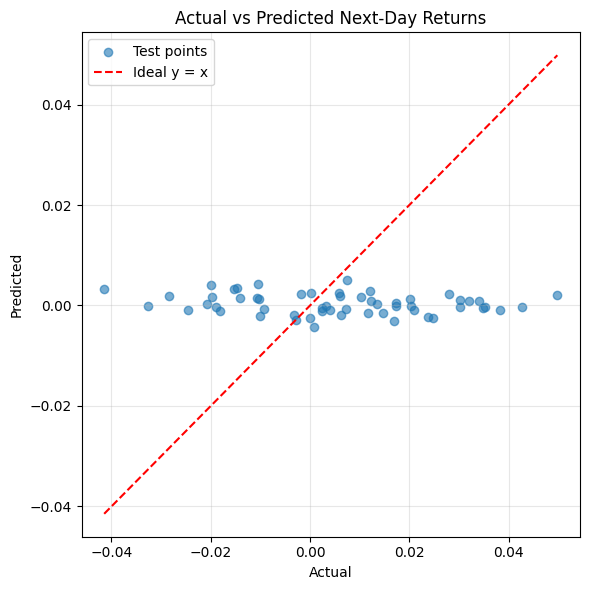

In [ ]:
# --- (b) MSE, R^2, Actual vs Predicted ---
y_pred = Xte_b @ beta
mse = np.mean((yte - y_pred) ** 2)
ss_res = np.sum((yte - y_pred) ** 2)
ss_tot = np.sum((yte - yte.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"MSE = {mse:.6e}")
print(f"R^2 = {r2:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(yte, y_pred, alpha=0.6, label='Test points')
lims = [min(yte.min(), y_pred.min()), max(yte.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal y = x')
plt.title('Actual vs Predicted Next-Day Returns')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.legend(); plt.tight_layout(); plt.show()

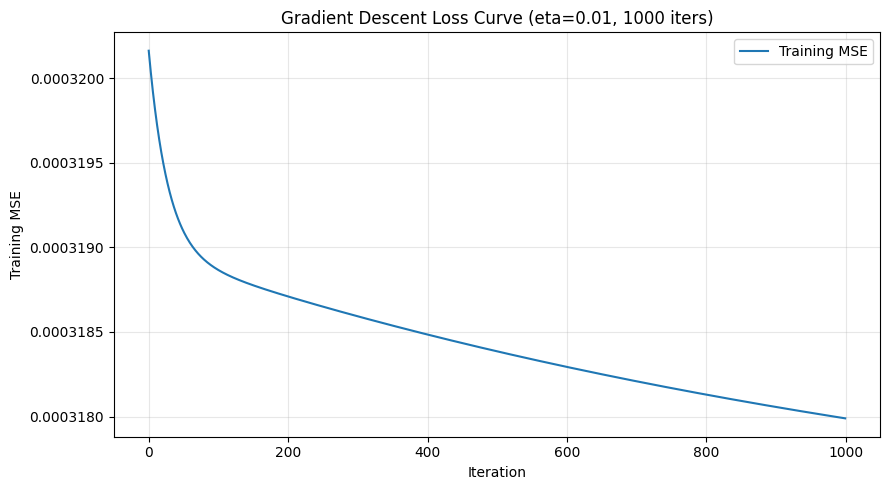

               NormalEq  GD_1000  GD_200k
bias            0.00667  0.00128  0.00587
Return_1d       0.00494  0.00107  0.00445
SMA_5           0.02946  0.00027  0.01569
SMA_20         -0.02751  0.00011 -0.01254
Volatility_10  -0.00546 -0.00163 -0.00566
Momentum_5     -0.01211  0.00009 -0.00954

Training MSE  -> NormalEq: 3.161e-04   GD(1000): 3.180e-04

With only 1000 iterations the individual GD coefficients are still far from the Normal-Equation values.
This is because SMA_5 and SMA_20 are highly collinear, so the loss surface is a long narrow valley that
GD crawls along slowly. Running ~200k iterations (column GD_200k) shows the coefficients do converge to
the closed-form solution. Note the *training MSE* is already nearly identical after 1000 steps — the fit
converges much faster than the individual (collinear) coefficients do.


In [ ]:
# --- (c) Batch Gradient Descent ---
def gradient_descent(Xb, yv, eta, iters):
    b = np.zeros(Xb.shape[1]); nb_ = len(yv); hist = []
    for _ in range(iters):
        b -= eta * (Xb.T @ (Xb @ b - yv)) / nb_
        hist.append(np.mean((Xb @ b - yv) ** 2))
    return b, hist

beta_gd, loss_hist = gradient_descent(Xtr_b, ytr, eta=0.01, iters=1000)   # as specified
beta_gd_long, _    = gradient_descent(Xtr_b, ytr, eta=0.01, iters=200000) # convergence demo

plt.figure()
plt.plot(loss_hist)
plt.title('Gradient Descent Loss Curve (eta=0.01, 1000 iters)')
plt.xlabel('Iteration'); plt.ylabel('Training MSE')
plt.legend(['Training MSE']); plt.tight_layout(); plt.show()

comp = pd.DataFrame({'NormalEq': beta, 'GD_1000': beta_gd, 'GD_200k': beta_gd_long},
                    index=coef_names)
print(comp.round(5))

# Compare the actual fit (predictions), which is what matters under collinearity
mse_ne = np.mean((Xtr_b @ beta     - ytr) ** 2)
mse_gd = np.mean((Xtr_b @ beta_gd  - ytr) ** 2)
print(f"\nTraining MSE  -> NormalEq: {mse_ne:.3e}   GD(1000): {mse_gd:.3e}")
print("\nWith only 1000 iterations the individual GD coefficients are still far from the "
      "Normal-Equation values.\nThis is because SMA_5 and SMA_20 are highly collinear, so the "
      "loss surface is a long narrow valley that\nGD crawls along slowly. Running ~200k "
      "iterations (column GD_200k) shows the coefficients do converge to\nthe closed-form "
      "solution. Note the *training MSE* is already nearly identical after 1000 steps — the "
      "fit\nconverges much faster than the individual (collinear) coefficients do.")

## Problem 8 — Portfolio Allocation with Linear Regression

We reuse the **Problem 7 model** ($\beta$ from the Normal Equation). Since Problem 1 has only
6 days (too short for 20-day features), we simulate a longer history for each of the 4 assets,
re-engineer the same features, scale them with the **training** min/max, and predict $\hat\mu_i$.

In [ ]:
def engineer_scaled(close, Xmin, Xmax):
    """Return scaled feature matrix + aligned next-day returns for a price series."""
    d = pd.DataFrame({'Close': close})
    d['Return_1d']     = d['Close'].pct_change()
    d['SMA_5']         = d['Close'].rolling(5).mean()
    d['SMA_20']        = d['Close'].rolling(20).mean()
    d['Volatility_10'] = d['Return_1d'].rolling(10).std()
    d['Momentum_5']    = d['Close'] - d['Close'].shift(5)
    d['next_ret']      = d['Return_1d'].shift(-1)
    d = d.dropna().reset_index(drop=True)
    Xs = (d[feature_cols].values - Xmin) / (Xmax - Xmin)
    return Xs, d['next_ret'].values

# Simulate 4 assets with slightly different drifts
np.random.seed(7)
assets = ['RELIANCE', 'INFY', 'HDFCBANK', 'TATAMOTORS']
drifts = [0.0012, 0.0008, 0.0005, 0.0015]
asset_prices = {a: 500 * np.cumprod(1 + np.random.normal(mu, 0.018, 260))
                for a, mu in zip(assets, drifts)}

# --- (a) Predict expected return per asset with the Problem-7 model ---
mu_hat, test_rets = {}, {}
for a in assets:
    Xs, nxt = engineer_scaled(asset_prices[a], X_min, X_max)
    s = int(0.8 * len(Xs))
    preds = add_bias(Xs[s:]) @ beta          # reuse trained beta
    mu_hat[a] = preds.mean()                  # expected return estimate
    test_rets[a] = nxt[s:]                     # actual test-period returns
mu_hat = pd.Series(mu_hat)
print("Predicted expected returns:\n", mu_hat.round(6))

Predicted expected returns:
 RELIANCE      0.002221
INFY          0.001885
HDFCBANK      0.000290
TATAMOTORS    0.000028
dtype: float64


In [ ]:
# --- (b) Weights proportional to positive predictions ---
pos = mu_hat.clip(lower=0)
ml_weights = pos / pos.sum() if pos.sum() > 0 else pd.Series(0.25, index=assets)
print("ML-driven weights:\n", ml_weights.round(4))
print("Sum of weights:", round(ml_weights.sum(), 6))

ML-driven weights:
 RELIANCE      0.5020
INFY          0.4260
HDFCBANK      0.0656
TATAMOTORS    0.0064
dtype: float64
Sum of weights: 1.0


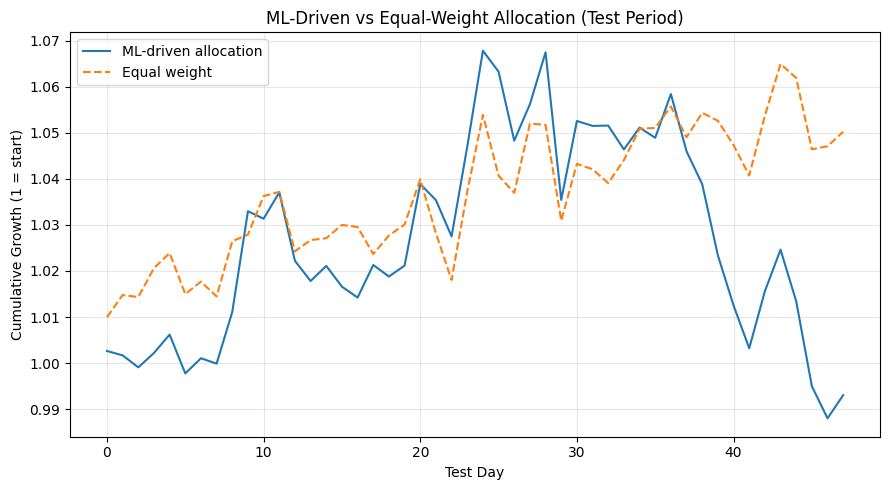

ML-driven final growth   : 0.9931
Equal-weight final growth: 1.0502

Limitation: weights are built from noisy next-day return predictions on a near-random walk, so any
out-performance is largely luck and won't be stable out-of-sample — the 'error-maximisation' problem of MVO.


In [ ]:
# --- (c) Backtest ML allocation vs equal weight ---
L = min(len(r) for r in test_rets.values())
R = np.column_stack([test_rets[a][:L] for a in assets])   # (L, 4) test returns

ml_port = R @ ml_weights.values
eq_port = R @ np.array([0.25]*4)
ml_cum = np.cumprod(1 + ml_port)
eq_cum = np.cumprod(1 + eq_port)

plt.figure()
plt.plot(ml_cum, label='ML-driven allocation')
plt.plot(eq_cum, label='Equal weight', linestyle='--')
plt.title('ML-Driven vs Equal-Weight Allocation (Test Period)')
plt.xlabel('Test Day'); plt.ylabel('Cumulative Growth (1 = start)')
plt.legend(); plt.tight_layout(); plt.show()

print(f"ML-driven final growth   : {ml_cum[-1]:.4f}")
print(f"Equal-weight final growth: {eq_cum[-1]:.4f}")
print("\nLimitation: weights are built from noisy next-day return predictions on a near-random "
      "walk, so any\nout-performance is largely luck and won't be stable out-of-sample — the "
      "'error-maximisation' problem of MVO.")

## Problem 9 — Model Comparison & Hyperparameter Tuning

In [ ]:
# --- (a) 5-fold CV for KNN (NumPy splitting, from scratch) ---
def kfold_indices(n, k, seed=0):
    idx = np.arange(n)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    return np.array_split(idx, k)

def cross_val_knn(X, y, k_knn, n_folds=5):
    folds = kfold_indices(len(X), n_folds)
    accs = []
    for i in range(n_folds):
        te_idx = folds[i]
        tr_idx = np.concatenate([folds[j] for j in range(n_folds) if j != i])
        pred = knn_predict(X[tr_idx], y[tr_idx], X[te_idx], k_knn)
        accs.append((pred == y[te_idx]).mean())
    return np.mean(accs), np.std(accs)

cv_results = {}
for kk in [3, 7, 11]:
    m, s = cross_val_knn(X_scaled, y, kk)
    cv_results[kk] = (m, s)
    print(f"k_KNN={kk:2d}  mean acc={m:.3f}  std={s:.3f}")

k_KNN= 3  mean acc=0.502  std=0.054


k_KNN= 7  mean acc=0.495  std=0.034


k_KNN=11  mean acc=0.523  std=0.024


In [ ]:
# --- (b) Summary DataFrame ---
best_cv_k = max(cv_results, key=lambda k: cv_results[k][0])
summary = pd.DataFrame({
    'Model': ['KNN Classifier', 'Linear Regression'],
    'Accuracy/R2': [round(cv_results[best_cv_k][0], 3), round(r2, 3)],
    'MSE/N.A.': ['N.A.', f'{mse:.2e}'],
    'Best Param': [f'k={best_cv_k}', 'Normal Eq.']
})
print(summary.to_string(index=False))

            Model  Accuracy/R2 MSE/N.A. Best Param
   KNN Classifier        0.523     N.A.       k=11
Linear Regression       -0.112 4.59e-04 Normal Eq.


In [ ]:
# --- (c) sklearn verification (allowed only here) ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

sk_knn = KNeighborsClassifier(n_neighbors=best_cv_k)
sk_acc = cross_val_score(sk_knn, X_scaled, y, cv=5).mean()

sk_lr = LinearRegression().fit(Xtr, ytr)
sk_r2 = sk_lr.score(Xte, yte)
print(f"sklearn KNN  5-fold accuracy : {sk_acc:.3f}   (scratch: {cv_results[best_cv_k][0]:.3f})")
print(f"sklearn LinReg R^2           : {sk_r2:.4f}   (scratch: {r2:.4f})")
print("\nDeployment: neither model shows a reliable edge (accuracy ~50%, R^2 ~0) on random-walk "
      "data, which is the\nhonest result. If forced to choose, the KNN classifier is more "
      "directly actionable for a directional signal,\nbut in practice neither is deployable "
      "as-is. Key live risks: (1) overfitting to backtest noise, and\n(2) look-ahead bias — "
      "using information that would not have been available in real time.")

sklearn KNN  5-fold accuracy : 0.509   (scratch: 0.523)
sklearn LinReg R^2           : -0.1124   (scratch: -0.1124)

Deployment: neither model shows a reliable edge (accuracy ~50%, R^2 ~0) on random-walk data, which is the
honest result. If forced to choose, the KNN classifier is more directly actionable for a directional signal,
but in practice neither is deployable as-is. Key live risks: (1) overfitting to backtest noise, and
(2) look-ahead bias — using information that would not have been available in real time.


---
## Section C — Conceptual & Critical Thinking

## Problem 10 — Theory, Design & Reflection

**(a) Diversification — the free lunch.**
Portfolio variance is $\sigma_p^2 = \sum_i w_i^2\sigma_i^2 + \sum_{i\neq j} w_i w_j \sigma_i \sigma_j \rho_{ij}$.
The first sum (individual variances) is fixed once weights are set, but the second sum scales with the
correlations $\rho_{ij}$. When assets have low or negative correlation, the cross terms shrink (or turn
negative), pulling total variance *below* the weighted average of individual risks. So one asset's losses
are partly cancelled by another's gains — you reduce risk without sacrificing expected return, which is
why Markowitz called it the only free lunch.

**(b) A fundamental feature for KNN.**
Add the **P/E ratio** (price-to-earnings). It captures valuation, which pure price-history features miss.
I'd obtain it from a fundamentals data source (e.g. an exchange/financials API or quarterly filings),
forward-fill it to a daily frequency to align with the price series, and append it as an extra (scaled)
column in the feature matrix so it contributes to the distance metric alongside the technical features.

**(c) Curse of dimensionality.**
As features grow, points spread out and inter-point distances become almost equal, so the notion of a
"nearest" neighbour loses meaning — everything is roughly equidistant. KNN's accuracy then degrades and it
needs exponentially more data to stay reliable, a serious issue for wide financial feature sets. Mitigation:
**dimensionality reduction** (e.g. PCA) or feature selection to keep only the most informative dimensions.

**(d) Backtest vs live gap (Sharpe 3.5 → 0.4).**
1. *Look-ahead bias* — using data unavailable at decision time; detect with strict point-in-time / walk-forward testing.
2. *Survivorship bias* — testing only on assets that survived; detect by rebuilding the universe with delisted names included.
3. *Data snooping / overfitting* — tuning until the backtest shines; detect with out-of-sample / nested cross-validation on untouched data.

**(e) Linear regression i.i.d. violations in finance.**
1. *Autocorrelation* — returns/residuals are serially correlated, so standard errors are understated and the model looks more confident than it is.
2. *Heteroskedasticity (volatility clustering)* — error variance changes over time (calm vs turbulent regimes), so predictions are unreliable exactly when risk is highest. Both break the i.i.d. assumption and distort inference.